<a href="https://colab.research.google.com/github/yangjingyi693-alt/molprop-bench/blob/main/notebooks/01_data_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 第一步：克隆仓库到 Colab 环境
!git clone https://github.com/yangjingyi693-alt/pharma-ai-journey
%cd pharma-ai-journey


Cloning into 'pharma-ai-journey'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'pharma-ai-journey'
/content


In [1]:
!pip install PyTDC --no-deps -q
!pip install openpyxl fuzzywuzzy python-Levenshtein -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.1.15 requires cellxgene-census==1.15.0, which is not installed.
pytdc 1.1.15 requires dataclasses<1.0,>=0.6, which is not installed.
pytdc 1.1.15 requires evaluate==0.4.2, which is not installed.
pytdc 1.1.15 requires gget<1.0.0,>=0.28.4, which is not installed.
pytdc 1.1.15 requires rdkit<2024.3.1,>=2023.9.5, which is not installed.
pytdc 1.1.15 requires tiledbsoma<2.0.0,>=1.7.2, which is not installed.
pytdc 1.1.15 requires accelerate==0.33.0, but you have accelerate 1.14.0 which is incompatible.
pytdc 1.1.15 requires datasets<2.2

In [2]:
import tdc
from tdc.single_pred import ADME

data = ADME(name='Caco2_Wang')
df = data.get_data()
df.head()

Downloading...
100%|██████████| 82.5k/82.5k [00:00<00:00, 716kiB/s]
Loading...
Done!


,Drug_ID,Drug,Y
0,(-)-epicatechin,Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2,-6.220000
1,"(2E,4Z,8Z)-N-isobutyldodeca-2,4,10-triene-8 -y...",C/C=C\C#CCC/C=C\C=C\C(=O)NCC(C)C,-3.860000
2,codeine,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,-4.090000
3,creatinine,CN1CC(=O)NC1=N,-5.935409
4,danazol,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,-4.840000


In [ ]:
from tdc.single_pred import Tox
data = Tox(name='hERG')
df = data.get_data()

Downloading...
100%|██████████| 50.2k/50.2k [00:00<00:00, 22.3MiB/s]
Loading...
Done!


In [3]:
import requests
import pandas as pd
import time
#准备API地址与参数
target_id="CHEMBL240"
#查数据的网址
url="https://www.ebi.ac.uk/chembl/api/data/activity"
all_activities=[]
limit=100 #最多一百条
offset=0  #从第0条开始

#循环分页请求
while True:  # 无限循环，直到遇到 break 跳出
    # 构造这一页的请求参数（告诉 API 你要什么）
    params = {
        "target_chembl_id": target_id,      # 指定靶点是 hERG
        "pchembl_value__isnull": "false",   # 只要 pChEMBL 值不为空的数据（后续需要这个值做二分类）
        "limit": limit,    # 当前页码
        "page_size": 100,    # 每页最多返回 100 条（ChEMBL 限制最大 100）
        "format": "json"   # 返回 JSON 格式（一种通用的数据交换格式）
    }

    # 发送 GET 请求（就像在浏览器地址栏输入网址并回车）
    # requests.get(url, params=params) 会返回一个响应对象
    response = requests.get(url, params=params)

    # 检查响应状态码：200 表示成功，其他数字表示出错
    if response.status_code != 200:
        print(f"❌ 请求失败，状态码: {response.status_code}")
        break  # 失败就退出循环

    # 将返回的 JSON 内容解析成 Python 字典（dict）
    # JSON 格式本质上是“键-值”对，和字典很像
    data_json = response.json()

    # 从返回的字典中取出 "activities" 这个键对应的值（一个列表）
    # .get("activities", []) 表示如果键不存在，就返回一个空列表 []
    activities = data_json.get("activities", [])

    # 如果这一页没有活动数据，说明已经翻到最后一页了，退出循环
    if not activities:
        break

    # 把这一页的活动数据添加到总列表里
    # extend() 会把列表中的元素一个个追加到 all_activities 末尾
    all_activities.extend(activities)

    # 打印当前已经拿到的数据条数
    total = data_json["page_meta"]["total_count"]   # 真正的总条数在这里
    print(f"已获取 {len(all_activities)}/{total}")
    print(f"已获取 {len(all_activities)}/{total}")
    offset+=limit
    if offset>=limit:
      break

    # 礼貌地等待3秒，减轻服务器压力，也避免被封 IP
    time.sleep(3)
#之前的毛病：total_pages = page_meta.get("total_pages", 1)ChEMBL API里面没有total_pages,所以只取了第一页的数据


#清洗数据
df = pd.DataFrame(all_activities)
print(f"抓取总量: {len(df)}")

# 只看活性类型分布，决定保留哪些
print(df['standard_type'].value_counts().head(10))

df = df.dropna(subset=['canonical_smiles'])
df = df[df['standard_type'].isin(['IC50', 'Ki', 'Kd', 'EC50'])]
print(f"清洗后: {len(df)}")

# 每个分子保留 pChEMBL 最好的一条
df = df.sort_values('pchembl_value', ascending=False)
df = df.drop_duplicates(subset='canonical_smiles', keep='first')

df.to_csv('raw.csv', index=False)
print(f"去重后: {len(df)} 条，已保存 raw.csv")


已获取 100/14263
已获取 100/14263
抓取总量: 100
standard_type
Ki      65
IC50    35
Name: count, dtype: int64
清洗后: 100
去重后: 96 条，已保存 raw.csv


In [4]:
import requests
import time

base_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
base_params = {
    "target_chembl_id": "CHEMBL240",
    "pchembl_value__isnull": "false",
    "limit": 1000,        # ChEMBL 单次允许的最大值
}

all_activities = []
offset = 0
fail_count = 0

while True:
    params = dict(base_params, offset=offset)
    r = requests.get(base_url, params=params)

    # 失败重试，最多连续 5 次，全部失败才退出
    if r.status_code != 200:
        fail_count += 1
        print(f"⚠️ offset={offset} 请求失败，状态码 {r.status_code}，第 {fail_count} 次重试")
        if fail_count >= 5:
            print("❌ 连续失败 5 次，退出")
            break
        time.sleep(5)
        continue
    fail_count = 0

    data = r.json()
    acts = data.get("activities", [])
    print(f"offset={offset}: 本页拿到 {len(acts)} 条")

    if not acts:
        print("本页为空，翻页结束")
        break

    all_activities.extend(acts)
    offset += len(acts)

    total = data["page_meta"]["total_count"]
    if offset >= total:
        break
    time.sleep(0.3)

print(f"✅ 抓取完成，共 {len(all_activities)} 条")

offset=0: 本页拿到 1000 条
offset=1000: 本页拿到 1000 条
offset=2000: 本页拿到 1000 条
offset=3000: 本页拿到 1000 条
offset=4000: 本页拿到 1000 条
offset=5000: 本页拿到 1000 条
offset=6000: 本页拿到 1000 条
offset=7000: 本页拿到 1000 条
offset=8000: 本页拿到 1000 条
offset=9000: 本页拿到 1000 条
offset=10000: 本页拿到 1000 条
offset=11000: 本页拿到 1000 条
offset=12000: 本页拿到 1000 条
offset=13000: 本页拿到 1000 条
offset=14000: 本页拿到 263 条
✅ 抓取完成，共 14263 条


In [5]:
import pandas as pd

print(f"抓取总量: {len(all_activities)}")
df = pd.DataFrame(all_activities)

df = df.dropna(subset=['canonical_smiles'])
df = df[df['standard_type'].isin(['IC50', 'Ki', 'Kd', 'EC50'])]

df = df.sort_values('pchembl_value', ascending=False)
df = df.drop_duplicates(subset='canonical_smiles', keep='first')

df.to_csv('raw.csv', index=False)
print(f"去重后: {len(df)} 条，已保存 raw.csv")

抓取总量: 14263
去重后: 11093 条，已保存 raw.csv


raw.csv ──读表──► df（内存里的表格）
        ──找列──► 确认哪一列是 pChEMBL
        ──质检──► 缺失值扔掉、数值范围检查
        ──打标──► pChEMBL≥6 → 1，否则 → 0
        ──画图──► 左：直方图   右：饼图
        ──存档──► labeled.csv

原始: 11093 行
筛 IC50 后: 9501 行
pChEMBL 列名: pchembl_value
质检通过，剩余: 9501 行
active: 2007 (21.1%)
inactive: 7494 (78.9%)


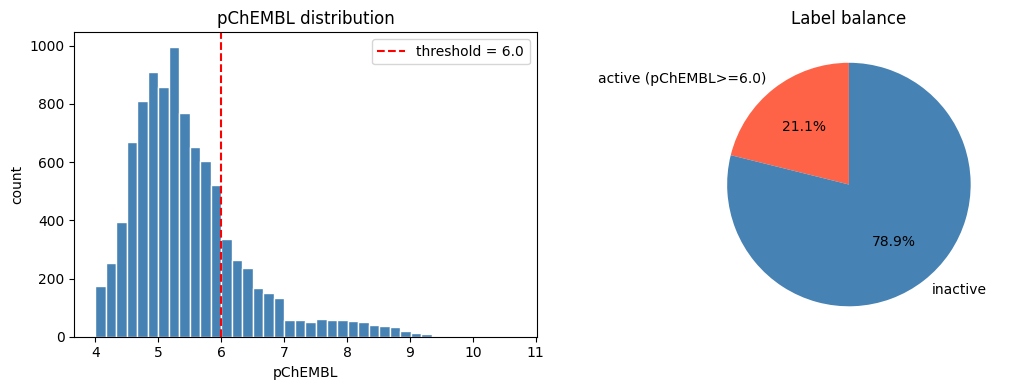

已保存: d1_eda.png, labeled.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- ① 读表 ----------
df = pd.read_csv('raw.csv')
print(f"原始: {len(df)} 行")

# ---------- ② 选A：筛 IC50 ----------
df = df[df['standard_type'] == 'IC50'].copy()
print(f"筛 IC50 后: {len(df)} 行")

# ---------- ③ 质检（你上一轮已验证过，这里是双保险） ----------
assert (df['standard_units'] == 'nM').all(), "存在非 nM 单位！"
assert (df['standard_relation'] == '=').all(), "存在模糊关系！"

# ---------- ④ 找到 pChEMBL 列 ----------
cand = [c for c in df.columns if 'pchembl' in c.lower()]
assert len(cand) == 1, f"pChEMBL 列不唯一: {cand}"
pcol = cand[0]
print(f"pChEMBL 列名: {pcol}")

# ---------- ⑤ 丢缺失 + 数值范围检查 ----------
df = df.dropna(subset=[pcol]).copy()
assert df[pcol].between(0, 15).all(), "pChEMBL 越界，检查单位！"
print(f"质检通过，剩余: {len(df)} 行")

# ---------- ⑥ 打标签（label 列在这里出生！）----------
THRESH = 6.0
df['label'] = (df[pcol] >= THRESH).astype(int)

# ---------- ⑦ 数 active/inactive ----------
n_act = int((df['label'] == 1).sum())
n_ina = int((df['label'] == 0).sum())
print(f"active: {n_act} ({n_act/len(df)*100:.1f}%)")
print(f"inactive: {n_ina} ({n_ina/len(df)*100:.1f}%)")
assert 0.05 < n_act/len(df) < 0.95, "类别比例极端！"

# ---------- ⑧ 画图 ----------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df[pcol], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(THRESH, color='r', ls='--', label=f'threshold = {THRESH}')
axes[0].set_xlabel('pChEMBL')
axes[0].set_ylabel('count')
axes[0].set_title('pChEMBL distribution')
axes[0].legend()

axes[1].pie([n_act, n_ina],
            labels=[f'active (pChEMBL>={THRESH})', 'inactive'],
            autopct='%.1f%%', colors=['tomato', 'steelblue'], startangle=90)
axes[1].set_title('Label balance')

plt.tight_layout()
plt.savefig('d1_eda.png', dpi=150)
plt.show()

# ---------- ⑨ 存档 ----------
df.to_csv('labeled.csv', index=False)
print("已保存: d1_eda.png, labeled.csv")

In [7]:
import pandas as pd, numpy as np

df = pd.read_csv('labeled.csv')                  # 读回你自己保存的文件
print('列名:', list(df.columns))                 # ① 先看有哪些列，后面才知道列名叫什么

# ② 三个"只要不对，后面全错"的前提检查
print('端点:', df['standard_type'].value_counts().to_dict())
print('单位:', df['standard_units'].value_counts().to_dict())
print('关系符:', df['standard_relation'].value_counts().to_dict())

# ③ 交叉验证：ChEMBL 给的 pchembl_value，我自己按公式算一遍，对不对得上
df['mine'] = 9 - np.log10(df['standard_value'])       # nM → pChEMBL
diff = (df['mine'] - df['pchembl_value']).abs().max()
print('最大差异:', round(diff, 4), '（应≈0）')


列名: ['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'modality', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value', 'label']
端点: {'IC50': 9501}
单位: {'nM': 9501}
关系符: {'=': 9501}
最大差异: 0.0055 （应≈0）


In [8]:
print('记录数  :', len(df))
print('唯一分子:', df['molecule_chembl_id'].nunique())


记录数  : 9501
唯一分子: 9501
